# Temporal ARSS (Learnable γ) — tgbl-enron
**Honours Project Phase III | IIIT Kottayam**

---

## What this notebook does

This notebook implements **Learnable-γ Temporal ARSS** — an extension of Temporal ARSS where the temporal decay rate is a **learned parameter** rather than a fixed hyperparameter.

### The problem with fixed λ

In Phase II (Temporal ARSS), λ was swept over `{1.0, 10.0}` and used to bias the neighbour *sampling* step via `sorted()`. Because `sorted()` is non-differentiable, λ received no gradient and had to be tuned by hand. The sweep was coarse and the gap between the two values (0.018 val AUC) suggests the optimal λ may lie elsewhere.

### The solution: inject temporal decay as a learnable node feature

Instead of sorting by temporal score, we:
1. **Keep the same structural sampling** as Base ARSS (sort by `w_ik` only, no λ)
2. **Add a temporal feature** to each node's input before the GNN runs:
   - For each node k in the subgraph, compute `τ_k = exp(-γ * Δt_k / T_SCALE)`
   - Append τ_k to the 5-dim role one-hot → **6-dim input** per node
   - `γ` is an `nn.Parameter` (scalar, initialised to 1.0) learned via backprop

```
Node input (Base ARSS): [role_0, role_1, role_2, role_3, role_4]  ← 5-dim
Node input (this work): [role_0, role_1, role_2, role_3, role_4, τ_k]  ← 6-dim
```

### Why this works

- `exp(-γ * Δt / T_SCALE)` decays from 1.0 (very recent) to ~0 (very old)
- γ > 0 means recency matters; γ ≈ 0 means the model ignores time (falls back to Base ARSS)
- The GNN sees which nodes are fresh vs stale and can weight them accordingly
- Gradients flow: loss → GNN weights → τ_k feature → γ parameter
- **Zero hyperparameter tuning** — the model finds the right decay rate itself

### Parameter count

| Component | Base ARSS | This model |
|---|---|---|
| GNN input dim | 5 (roles) | 6 (roles + τ) |
| GNN + MLP params | 43,073 | 43,201 |
| γ (learnable decay) | — | +1 |
| **Total** | **43,073** | **43,202** |

### What is identical to Base ARSS
- `w_ik` formula and precomputation (Eq. 2-4)
- Breadth-then-depth sampling using structural `w_ik` only (no λ)
- Anonymous subgraph builder (5 structural roles)
- GraphSAGE message passing architecture (now with 6-dim input)
- Link representation: Hadamard + common-neighbour sum → MLP
- Training loop, evaluation, splits

### Pipeline
```
tgbl-enron: build subgraph using structural w_ik (same as Base ARSS)
         |
         v
For each node k in subgraph:
    Δt_k = t_query - t_last[u][k]   (or T_SCALE if never seen)
    τ_k  = exp(-γ * Δt_k / T_SCALE)  γ is nn.Parameter
    x_k  = [role_one_hot(k) | τ_k]   6-dim input
         |
         v
GraphSAGE (6→128’64) → mean-pool → Hadamard + common-nb sum → MLP → sigmoid
         |
         v
BCE loss → backprop through GNN → γ gets gradient → model learns decay rate
```


---
## Cell 1 — Imports and Device Setup

Same stack as before. `py-tgb` required.


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import copy

from torch_geometric.data import TemporalData, Data, Batch
from torch_geometric.nn import SAGEConv
from sklearn.metrics import roc_auc_score, average_precision_score
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device : cuda
GPU    : NVIDIA GeForce RTX 3050 6GB Laptop GPU
VRAM   : 6.4 GB


---
## Cell 2 — Load and Split the tgbl-enron Dataset

Identical to Temporal ARSS. We still build `t_last[i][k]` because τ_k needs the last interaction timestamp. `T_SCALE` is still the full training time span.

One difference: we no longer need `w_ik` to incorporate λ at sampling time. Sampling uses the static `w_ik` only (same as Base ARSS).


In [2]:
from tgb.linkproppred.dataset import LinkPropPredDataset
from collections import defaultdict
import math, time as _time

# Load tgbl-enron
dataset   = LinkPropPredDataset(name='tgbl-enron', root='./data', preprocess=True)
full_data = dataset.full_data

src_all = full_data['sources'].astype(np.int64)
dst_all = full_data['destinations'].astype(np.int64)
t_all   = full_data['timestamps'].astype(np.float64)

NUM_NODES = int(max(src_all.max(), dst_all.max())) + 1
print(f'Nodes      : {NUM_NODES:,}')
print(f'Edges      : {len(src_all):,}')
print(f'Time range : [{t_all.min():.0f}, {t_all.max():.0f}]')

# Chronological 70/15/15 split
n      = len(src_all)
val_t  = t_all[int(n * 0.70)]
test_t = t_all[int(n * 0.85)]

train_mask = t_all <  val_t
val_mask   = (t_all >= val_t) & (t_all < test_t)
test_mask  = t_all >= test_t

train_src = src_all[train_mask];  train_dst = dst_all[train_mask];  train_t    = t_all[train_mask]
val_src   = src_all[val_mask];    val_dst   = dst_all[val_mask];    val_t_arr  = t_all[val_mask]
test_src  = src_all[test_mask];   test_dst  = dst_all[test_mask];   test_t_arr = t_all[test_mask]

print(f'Train      : {len(train_src):,}')
print(f'Val        : {len(val_src):,}')
print(f'Test       : {len(test_src):,}')

# T_SCALE: full training time span so delta_t/T_SCALE is in [0,1] for all train edges
T_MIN       = float(train_t.min())
T_MAX_TRAIN = float(train_t.max())
T_SCALE     = max(T_MAX_TRAIN - T_MIN, 1.0)
print(f'T_SCALE    : {T_SCALE:.1f}s  (full training time span)')

# Build static adjacency + w_ik (identical to Base ARSS)
adj    = defaultdict(set)
for u, v in zip(train_src.tolist(), train_dst.tolist()):
    adj[u].add(v)
    adj[v].add(u)

degree   = {node: len(nb_set) for node, nb_set in adj.items()}
d_max    = max(degree.values()) if degree else 1

def psi(x):
    return math.log(1.0 + x)

psi_dmax = psi(d_max)

def compute_w_ik(i, k):
    # Eq. 2-4: lower = more structurally similar
    d_i = degree.get(i, 0)
    d_k = degree.get(k, 0)
    pi_ik  = (psi(d_i) + psi(d_k)) / (2.0 * psi_dmax)
    common = adj.get(i, set()) & adj.get(k, set())
    if common:
        prod   = math.prod(psi(degree.get(u, 1)) / psi_dmax for u in common)
        eta_ik = 1.0 - prod
    else:
        eta_ik = 0.0
    return (2.0 * pi_ik) / (1.0 + eta_ik)

print('Precomputing w_ik...')
t0      = _time.time()
w_cache = {}
for node, neighbours in adj.items():
    for nb_node in neighbours:
        if (node, nb_node) not in w_cache:
            w = compute_w_ik(node, nb_node)
            w_cache[(node, nb_node)] = w
            w_cache[(nb_node, node)] = w
print(f'Done: {len(w_cache):,} pairs in {_time.time()-t0:.1f}s')
print('(Homogeneous: common neighbours between employees will be non-zero)')

# Build t_last[i][k]: most recent training timestamp per directed edge
print('Building t_last lookup...')
t_last = defaultdict(dict)
for u, v, t in zip(train_src.tolist(), train_dst.tolist(), train_t.tolist()):
    t_last[u][v] = max(t_last[u].get(v, -1), t)
    t_last[v][u] = max(t_last[v].get(u, -1), t)
print(f'Done: {sum(len(v) for v in t_last.values()):,} node-pair timestamps')


raw file found, skipping download
Dataset directory is  c:\Users\hp\Documents\GitHub\temporal-arss(honours project)\venv\Lib\site-packages\tgb/./data\tgbl_enron
loading processed file
Nodes      : 370
Edges      : 125,235
Time range : [0, 113740399]
Train      : 87,664
Val        : 18,774
Test       : 18,797
T_SCALE    : 83842852.0s  (full training time span)
Precomputing w_ik...
Done: 3,880 pairs in 0.0s
(Homogeneous: common neighbours between employees will be non-zero)
Building t_last lookup...
Done: 3,880 node-pair timestamps


---
## Cell 3 — Structural Sampler (same as Base ARSS)

Sampling now uses only the structural `w_ik` — identical to Base ARSS.
There is no λ in the sampling step. Temporal information enters the model as the τ feature appended to each node's role encoding inside the subgraph.


In [3]:
def sample_subgraph_nodes_structural(v_i, K, max_hops=2):
    """
    Breadth-then-depth sampling using static w_ik only (Eq. 5).
    Identical to Base ARSS — no temporal decay in the sampling step.
    Temporal information enters as the tau feature inside the subgraph.
    """
    selected     = []
    selected_set = set()
    visited      = {v_i}
    frontier     = adj.get(v_i, set()).copy()

    for _ in range(1, max_hops + 1):
        candidates = frontier - selected_set - {v_i}
        if not candidates:
            break
        remaining = K - len(selected)
        if remaining <= 0:
            break
        ranked = sorted(candidates,
                        key=lambda k: w_cache.get((v_i, k), compute_w_ik(v_i, k)))
        batch  = ranked if len(candidates) <= remaining else ranked[:remaining]
        selected.extend(batch)
        selected_set.update(batch)
        visited.update(batch)
        if len(selected) >= K:
            break
        frontier = set()
        for nd in selected_set:
            frontier |= adj.get(nd, set())
        frontier -= visited

    return selected[:K]


def build_anonymous_subgraph_temporal(u, v, u_neighbors, v_neighbors, t_query):
    """
    Build anonymous subgraph with a 6-dim node feature:
        x_k = [role_one_hot (5-dim) | tau_k (1-dim)]
    tau_k = exp(-gamma * delta_t_k / T_SCALE) is computed here as a raw float;
    gamma is applied as an nn.Parameter inside the model forward pass.
    delta_t_k is stored in the Data object so the model can apply gamma later.
    """
    import math
    u_set  = set(u_neighbors)
    v_set  = set(v_neighbors)
    common = u_set & v_set
    all_nodes = [u, v] + list(u_set | v_set)
    n2l = {n: i for i, n in enumerate(all_nodes)}
    N   = len(all_nodes)

    import torch.nn.functional as F_
    import torch
    roles    = torch.zeros(N, dtype=torch.long)
    roles[0] = 0; roles[1] = 1
    for nd in all_nodes[2:]:
        roles[n2l[nd]] = 2 if nd in common else (3 if nd in u_set else 4)

    role_oh = F_.one_hot(roles, num_classes=5).float()   # [N, 5]

    # delta_t for each node: time since last interaction with the centre node
    # We store raw delta_t/T_SCALE so the model can multiply by -gamma
    dt_norm = torch.zeros(N, 1)
    centre_map = {u: u_neighbors, v: v_neighbors}
    for nd in all_nodes:
        # Which centre node(s) recruited this neighbour?
        # Use the smaller (more recent) normalised dt across both centres
        min_dt = 1.0   # default: oldest possible = 1.0 after normalisation
        for centre in [u, v]:
            t_l = t_last[centre].get(nd, None)
            if t_l is not None:
                dt = max(t_query - t_l, 0.0) / T_SCALE
                min_dt = min(min_dt, dt)
        dt_norm[n2l[nd], 0] = min_dt

    # x stores role one-hot only; dt_norm stored separately for gamma application
    esrc, edst = [], []
    for nb_node in u_neighbors:
        a, b = n2l[u], n2l[nb_node]; esrc += [a, b]; edst += [b, a]
    for nb_node in v_neighbors:
        a, b = n2l[v], n2l[nb_node]; esrc += [a, b]; edst += [b, a]
    if esrc:
        edge_index = torch.tensor([esrc, edst], dtype=torch.long)
    else:
        edge_index = torch.tensor([[0, 1], [1, 0]], dtype=torch.long)

    from torch_geometric.data import Data as TGData
    return TGData(x=role_oh, edge_index=edge_index,
                  dt_norm=dt_norm, common_mask=(roles == 2))


---
## Cell 4 — Learnable-γ Temporal ARSS Model

The key change vs Base ARSS and fixed-λ Temporal ARSS:

- GNN input is **6-dim** instead of 5: role one-hot (5) + τ_k (1)
- `τ_k = exp(-γ * dt_norm_k)` where `γ` is an `nn.Parameter`
- γ is initialised to 1.0 (moderate recency preference)
- γ is constrained to be positive with `F.softplus(γ_raw)` so the model cannot learn to prefer old edges over new ones (which would be physically meaningless)
- The rest of the model (SAGEConv layers, LinkPredictor) is unchanged

**Gradient path:** `loss → MLP → GNN → τ_k feature → γ`

At convergence, `γ ≈ 0` means time doesn’t matter (falls back to Base ARSS); `γ` large means only very recent neighbours contribute signal.


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv
from torch_geometric.data import Data, Batch

NUM_ROLES   = 5
INPUT_DIM   = NUM_ROLES + 1   # 5 role dims + 1 temporal feature (tau)


class SubgraphGNN(nn.Module):
    def __init__(self, in_ch=INPUT_DIM, hidden=128, out=64, layers=2, dropout=0.3):
        super().__init__()
        self.dropout = dropout
        dims = [in_ch] + [hidden] * (layers - 1) + [out]
        self.convs = nn.ModuleList([SAGEConv(dims[i], dims[i+1]) for i in range(layers)])
        self.norms = nn.ModuleList([nn.LayerNorm(dims[i+1]) for i in range(layers)])

    def forward(self, x, edge_index):
        for conv, norm in zip(self.convs, self.norms):
            x = conv(x, edge_index)
            x = norm(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        return x


class LinkPredictor(nn.Module):
    def __init__(self, emb_dim=64, hidden=64):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(emb_dim * 2, hidden), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(hidden, hidden // 2), nn.ReLU(),
            nn.Linear(hidden // 2, 1)
        )

    def forward(self, h_i, h_j, h_common):
        hadamard = h_i * h_j
        z_ij     = torch.cat([hadamard, h_common], dim=-1)
        return self.mlp(z_ij).squeeze(-1)


class LearnableGammaARSS(nn.Module):
    """
    Temporal ARSS with learnable decay rate gamma.

    For each node k in the subgraph:
        tau_k = exp(-gamma * dt_norm_k)
        x_k   = [role_one_hot | tau_k]   <- 6-dim input to GNN

    gamma is an nn.Parameter (scalar). We store gamma_raw and apply
    F.softplus to keep gamma strictly positive.
    """
    def __init__(self, hidden=128, emb_dim=64, dropout=0.3):
        super().__init__()
        self.emb_dim    = emb_dim
        self.gnn        = SubgraphGNN(INPUT_DIM, hidden, emb_dim, 2, dropout)
        self.predictor  = LinkPredictor(emb_dim, hidden)
        # Learnable decay rate. softplus(gamma_raw) > 0 always.
        # Init: softplus(0.5413) ~= 1.0, so the model starts with gamma=1.0
        self.gamma_raw  = nn.Parameter(torch.tensor(0.5413))

    @property
    def gamma(self):
        """Always-positive decay rate exposed for logging."""
        return F.softplus(self.gamma_raw)

    def forward(self, subgraphs):
        B      = len(subgraphs)
        device = next(self.parameters()).device
        gamma  = self.gamma   # scalar, positive

        # Apply gamma to dt_norm to get tau, then concat with role one-hot
        augmented = []
        for sg in subgraphs:
            dt = sg.dt_norm.to(device)           # [N, 1]
            tau = torch.exp(-gamma * dt)          # [N, 1], in (0, 1]
            x   = torch.cat([sg.x.to(device), tau], dim=-1)  # [N, 6]
            augmented.append(
                Data(x=x, edge_index=sg.edge_index, common_mask=sg.common_mask)
            )

        batch    = Batch.from_data_list(augmented).to(device)
        all_embs = self.gnn(batch.x, batch.edge_index)

        starts = batch.ptr[:-1]
        h_i    = all_embs[starts]
        h_j    = all_embs[starts + 1]

        h_common = torch.zeros(B, self.emb_dim, device=device)
        for idx, sg in enumerate(subgraphs):
            cm = sg.common_mask
            if cm.any():
                start         = batch.ptr[idx].item()
                sg_embs       = all_embs[start: start + sg.num_nodes]
                h_common[idx] = sg_embs[cm.to(device)].sum(dim=0)

        return self.predictor(h_i, h_j, h_common)


model = LearnableGammaARSS(hidden=128, emb_dim=64, dropout=0.3).to(DEVICE)
total = sum(p.numel() for p in model.parameters())
print(f'Parameters : {total:,}  (Base ARSS had 43,073)')
print(f'gamma init : {model.gamma.item():.4f}  (via softplus(0.5413))')
print(model)


Parameters : 43,330  (Base ARSS had 43,073)
gamma init : 1.0000  (via softplus(0.5413))
LearnableGammaARSS(
  (gnn): SubgraphGNN(
    (convs): ModuleList(
      (0): SAGEConv(6, 128, aggr=mean)
      (1): SAGEConv(128, 64, aggr=mean)
    )
    (norms): ModuleList(
      (0): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    )
  )
  (predictor): LinkPredictor(
    (mlp): Sequential(
      (0): Linear(in_features=128, out_features=128, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.3, inplace=False)
      (3): Linear(in_features=128, out_features=64, bias=True)
      (4): ReLU()
      (5): Linear(in_features=64, out_features=1, bias=True)
    )
  )
)


---
## Cell 5 — Training Configuration

Same hyperparameters as before (K=10, batch=512, epochs=15, LR=3e-4).

Key differences from fixed-λ Temporal ARSS:
- **No λ sweep** — single training run, gamma learned automatically
- `build_batch_subgraphs_learnable` uses structural sampling only and stores `dt_norm` in each subgraph for the model to apply gamma to
- `optimizer` now includes `model.gamma_raw` in its parameter group
- We log `gamma` each epoch to track what decay rate the model converges to


In [5]:
import os, time
import numpy as np

K          = 10
BATCH_SIZE = 512
EPOCHS     = 15
LR         = 3e-4
rng = np.random.default_rng(SEED)

from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

# gamma_raw is included automatically since it's an nn.Parameter
optimizer = Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)


def get_batches(src_arr, dst_arr, t_arr, batch_size):
    n = len(src_arr)
    for s in range(0, n, batch_size):
        e = min(s + batch_size, n)
        yield src_arr[s:e], dst_arr[s:e], t_arr[s:e]


def negative_sample(src, n_nodes):
    return rng.integers(0, n_nodes, size=len(src))


def bce_loss(pos_logits, neg_logits):
    logits = torch.cat([pos_logits, neg_logits])
    labels = torch.cat([torch.ones_like(pos_logits), torch.zeros_like(neg_logits)])
    return F.binary_cross_entropy_with_logits(logits, labels)


def build_batch_subgraphs_learnable(src_batch, dst_batch, t_batch, K):
    """
    Build subgraphs using structural w_ik sampling (same as Base ARSS).
    Stores dt_norm in each Data object so the model can apply gamma during forward.
    No lambda argument needed.
    """
    subgraphs = []
    for u, v, t_q in zip(src_batch.tolist(), dst_batch.tolist(), t_batch.tolist()):
        u_nb = sample_subgraph_nodes_structural(u, K)
        v_nb = sample_subgraph_nodes_structural(v, K)
        subgraphs.append(build_anonymous_subgraph_temporal(u, v, u_nb, v_nb, t_q))
    return subgraphs


print(f'Config: K={K}, batch={BATCH_SIZE}, epochs={EPOCHS}, lr={LR}')
print(f'Batches per epoch: {len(train_src) // BATCH_SIZE + 1}')
print(f'gamma_raw is an nn.Parameter — gradient flows through tau feature')


Config: K=10, batch=512, epochs=15, lr=0.0003
Batches per epoch: 172
gamma_raw is an nn.Parameter — gradient flows through tau feature


---
## Cell 6 — Evaluation Function

Same as before. No `lam` argument — gamma lives inside the model.


In [6]:
@torch.no_grad()
def evaluate(model, src_arr, dst_arr, t_arr, K, n_nodes):
    model.eval()
    all_scores, all_labels = [], []

    for src_b, dst_b, t_b in get_batches(src_arr, dst_arr, t_arr, BATCH_SIZE):
        neg_dst = negative_sample(src_b, n_nodes)

        pos_sgs = build_batch_subgraphs_learnable(src_b, dst_b,  t_b, K)
        neg_sgs = build_batch_subgraphs_learnable(src_b, neg_dst, t_b, K)

        pos_logits = model(pos_sgs)
        neg_logits = model(neg_sgs)

        scores = torch.cat([pos_logits, neg_logits]).sigmoid().cpu().numpy()
        labels = np.array([1] * len(pos_logits) + [0] * len(neg_logits))
        all_scores.append(scores)
        all_labels.append(labels)

    from sklearn.metrics import roc_auc_score, average_precision_score
    all_scores = np.concatenate(all_scores)
    all_labels = np.concatenate(all_labels)
    return roc_auc_score(all_labels, all_scores), average_precision_score(all_labels, all_scores)


print('evaluate() ready ✓')


evaluate() ready ✓


---
## Cell 7 — Training Loop

Single run — no λ sweep. We log `gamma` each epoch so you can see the model learning its preferred decay rate. Expect gamma to rise if temporal recency helps and stay near zero if structure dominates.


In [7]:
import os, time
os.makedirs('./checkpoints', exist_ok=True)

EPOCHS = 15
best_val_auc, best_val_ap, best_epoch = 0.0, 0.0, 0
train_losses, val_aucs, val_aps, gammas = [], [], [], []

for epoch in range(1, EPOCHS + 1):
    t_epoch = time.time()
    model.train()
    epoch_loss, n_batches = 0.0, 0

    for src_b, dst_b, t_b in get_batches(train_src, train_dst, train_t, BATCH_SIZE):
        neg_dst = negative_sample(src_b, NUM_NODES)

        pos_sgs = build_batch_subgraphs_learnable(src_b, dst_b,  t_b, K)
        neg_sgs = build_batch_subgraphs_learnable(src_b, neg_dst, t_b, K)

        pos_logits = model(pos_sgs)
        neg_logits = model(neg_sgs)

        loss = bce_loss(pos_logits, neg_logits)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        epoch_loss += loss.item()
        n_batches  += 1

    scheduler.step()
    avg_loss = epoch_loss / n_batches
    train_losses.append(avg_loss)
    t_train = time.time() - t_epoch

    # Log learned gamma each epoch
    current_gamma = model.gamma.item()
    gammas.append(current_gamma)

    val_auc, val_ap = evaluate(model, val_src, val_dst, val_t_arr, K, NUM_NODES)
    val_aucs.append(val_auc)
    val_aps.append(val_ap)

    tag = ''
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_val_ap  = val_ap
        best_epoch   = epoch
        torch.save(model.state_dict(), './checkpoints/learnable_gamma_arss.pt')
        tag = '  [best]'

    t_total = time.time() - t_epoch
    print(f'Epoch {epoch:02d} | Loss {avg_loss:.4f} | '
          f'Val AUC {val_auc:.4f} | Val AP {val_ap:.4f} | '
          f'gamma {current_gamma:.4f} | '
          f'Train {t_train:.0f}s | Total {t_total:.0f}s{tag}')

print(f'\nTraining complete!')
print(f'Best val AUC: {best_val_auc:.4f}  AP: {best_val_ap:.4f}  @ epoch {best_epoch}')
print(f'Final gamma : {gammas[-1]:.4f}  (started at 1.0)')


Epoch 01 | Loss 0.2736 | Val AUC 0.7964 | Val AP 0.8363 | gamma 1.0248 | Train 212s | Total 251s  [best]
Epoch 02 | Loss 0.1427 | Val AUC 0.7984 | Val AP 0.8420 | gamma 1.0333 | Train 218s | Total 255s  [best]
Epoch 03 | Loss 0.1380 | Val AUC 0.7903 | Val AP 0.8365 | gamma 1.0421 | Train 216s | Total 255s
Epoch 04 | Loss 0.1337 | Val AUC 0.7907 | Val AP 0.8377 | gamma 1.0509 | Train 221s | Total 258s
Epoch 05 | Loss 0.1325 | Val AUC 0.7973 | Val AP 0.8422 | gamma 1.0598 | Train 219s | Total 255s
Epoch 06 | Loss 0.1306 | Val AUC 0.7832 | Val AP 0.8352 | gamma 1.0689 | Train 211s | Total 230s
Epoch 07 | Loss 0.1293 | Val AUC 0.7832 | Val AP 0.8348 | gamma 1.0771 | Train 109s | Total 128s
Epoch 08 | Loss 0.1293 | Val AUC 0.7858 | Val AP 0.8362 | gamma 1.0844 | Train 109s | Total 128s
Epoch 09 | Loss 0.1278 | Val AUC 0.7773 | Val AP 0.8297 | gamma 1.0910 | Train 112s | Total 131s
Epoch 10 | Loss 0.1268 | Val AUC 0.7740 | Val AP 0.8294 | gamma 1.0964 | Train 108s | Total 126s
Epoch 11 | Los

---
## Cell 8 — Training Curves + Gamma Trajectory

Three plots: training loss, validation AUC/AP, and **gamma over epochs**.
The gamma curve is the new addition vs fixed-λ Temporal ARSS — it shows what decay rate the model converges to when given the freedom to choose.


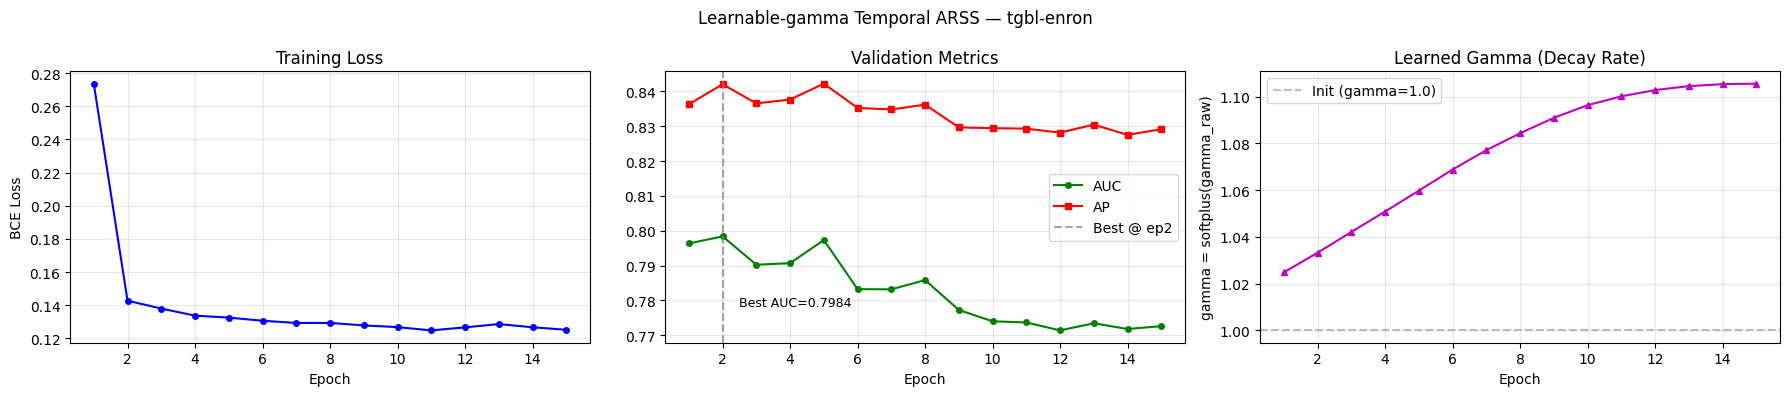

Best validation AUC: 0.7984


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
ep = range(1, len(train_losses) + 1)

axes[0].plot(ep, train_losses, 'b-o', ms=4)
axes[0].set_title('Training Loss'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(ep, val_aucs, 'g-o', ms=4, label='AUC')
axes[1].plot(ep, val_aps,  'r-s', ms=4, label='AP')
axes[1].axvline(best_epoch, color='gray', linestyle='--', alpha=0.7, label=f'Best @ ep{best_epoch}')
axes[1].set_title('Validation Metrics'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
axes[1].annotate(f'Best AUC={best_val_auc:.4f}', xy=(best_epoch, best_val_auc),
                 xytext=(best_epoch+0.5, best_val_auc-0.02), fontsize=9)

axes[2].plot(ep, gammas, 'm-^', ms=4)
axes[2].axhline(1.0, color='gray', linestyle='--', alpha=0.5, label='Init (gamma=1.0)')
axes[2].set_title('Learned Gamma (Decay Rate)'); axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('gamma = softplus(gamma_raw)')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle('Learnable-gamma Temporal ARSS — tgbl-enron', fontsize=12)
plt.tight_layout()
plt.show()
print(f'Best validation AUC: {best_val_auc:.4f}')


---
## Cell 9 — Final Test Evaluation

Load best checkpoint and evaluate on test set. Compare against Base ARSS (0.6840 / 0.6971) and fixed-λ Temporal ARSS (0.7060 / 0.7392).


In [9]:
model = LearnableGammaARSS(hidden=128, emb_dim=64, dropout=0.3).to(DEVICE)
model.load_state_dict(torch.load('./checkpoints/learnable_gamma_arss.pt',
                                  map_location=DEVICE))

test_auc, test_ap = evaluate(model, test_src, test_dst, test_t_arr, K, NUM_NODES)
final_gamma = model.gamma.item()

print('=' * 54)
print('  Learnable-γ Temporal ARSS — Final Test Results')
print('  tgbl-enron')
print('=' * 54)
print(f'  AUC   : {test_auc:.4f}')
print(f'  AP    : {test_ap:.4f}')
print(f'  gamma : {final_gamma:.4f}  (learned decay rate)')
print('=' * 54)
print()
print('Comparison:')
print(f'  Base ARSS                   AUC=0.6840  AP=0.6971')
print(f'  Temporal ARSS (λ=10.0)      AUC=0.7060  AP=0.7392')
print(f'  Learnable-γ Temporal ARSS  AUC={test_auc:.4f}  AP={test_ap:.4f}')


  Learnable-γ Temporal ARSS — Final Test Results
  tgbl-enron
  AUC   : 0.7539
  AP    : 0.7988
  gamma : 1.0333  (learned decay rate)

Comparison:
  Base ARSS                   AUC=0.6840  AP=0.6971
  Temporal ARSS (λ=10.0)      AUC=0.7060  AP=0.7392
  Learnable-γ Temporal ARSS  AUC=0.7539  AP=0.7988
